Phase0 shift (My QCW -> last TOA tref): 5.1980 rad
Loading Loki samples (1M, lastTOA tref)...
  Loki (full): (1000000, 5)
  Loki (subsampled): (75000, 5)
Loading my QCW dL-masked samples...
  My QCW (full): (126372, 5)
  My QCW (subsampled): (75000, 5)
Loading Enterprise samples...
  Enterprise (full): (72001, 5)
  Enterprise (subsampled): (72001, 5)

Panel 1: My QCW vs Loki


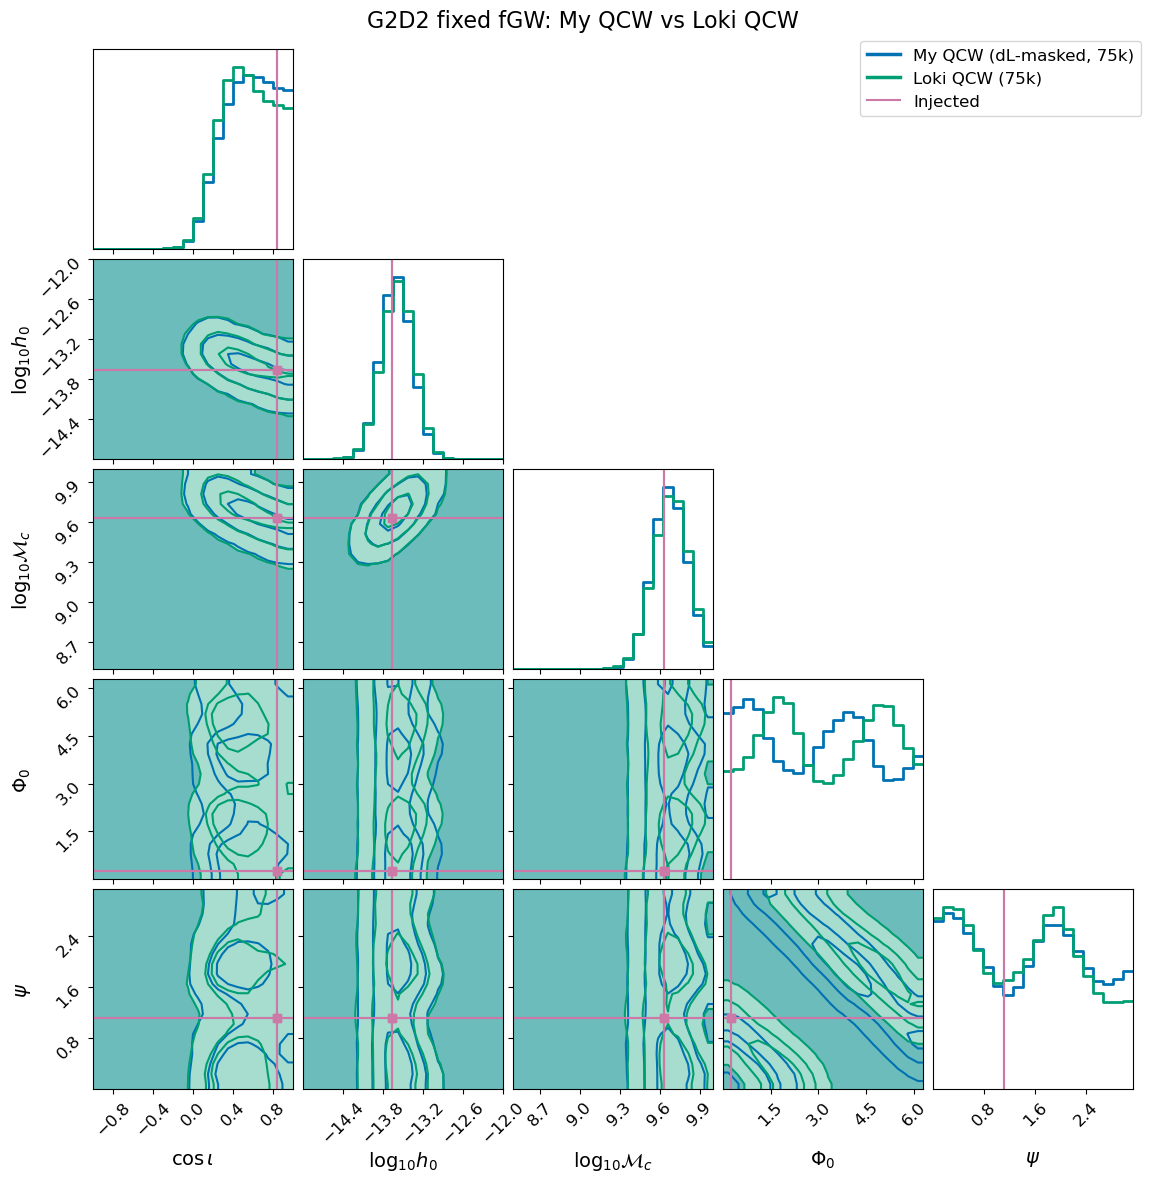

Panel 2: Loki vs Enterprise


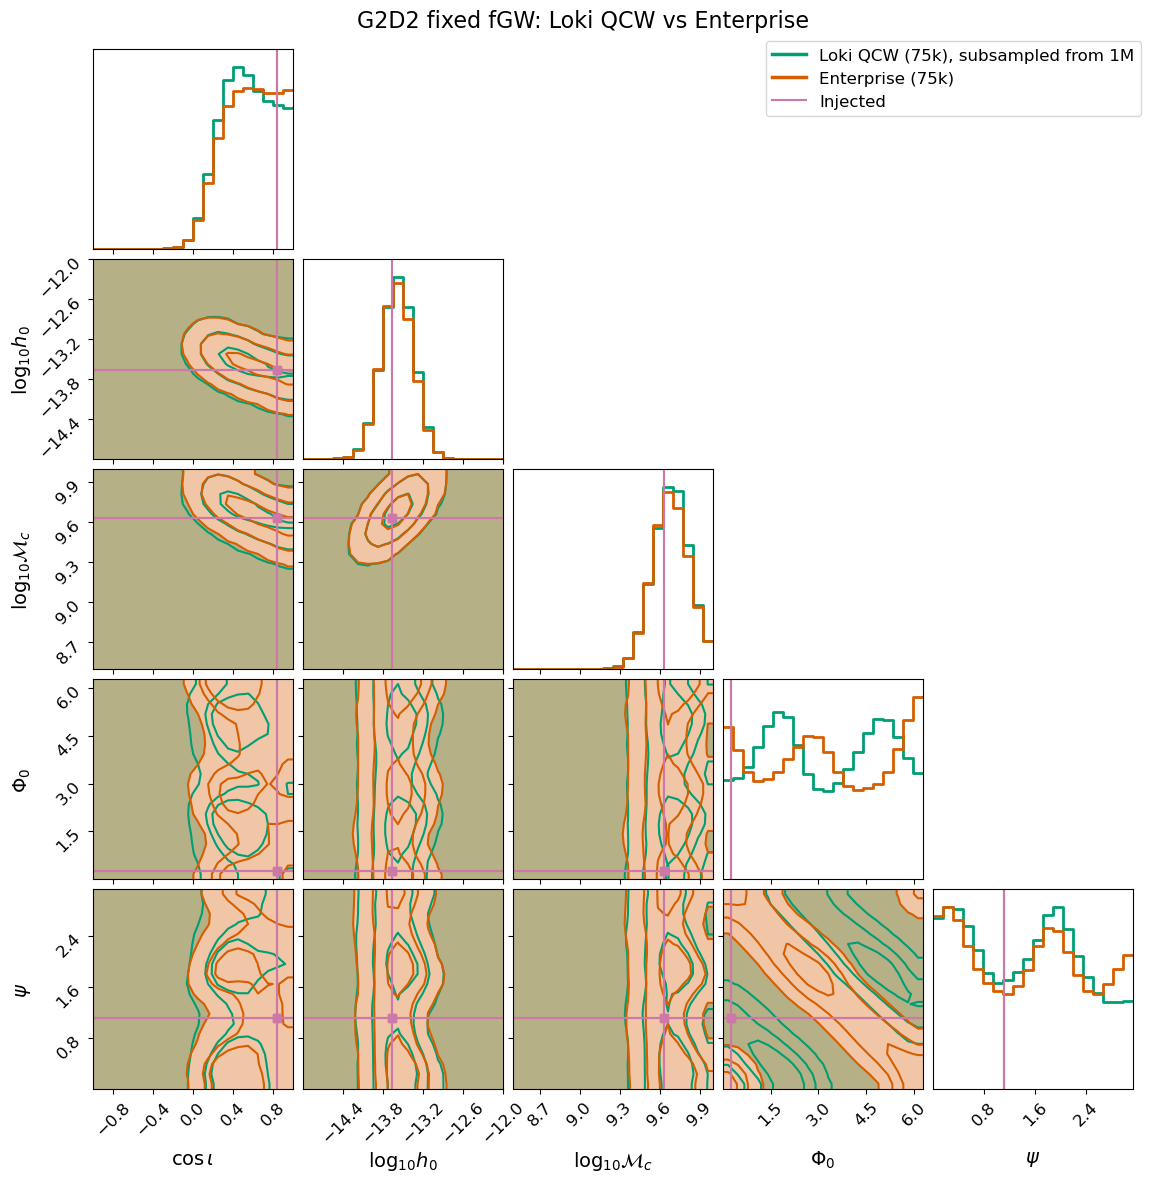

Panel 3: My QCW vs Enterprise


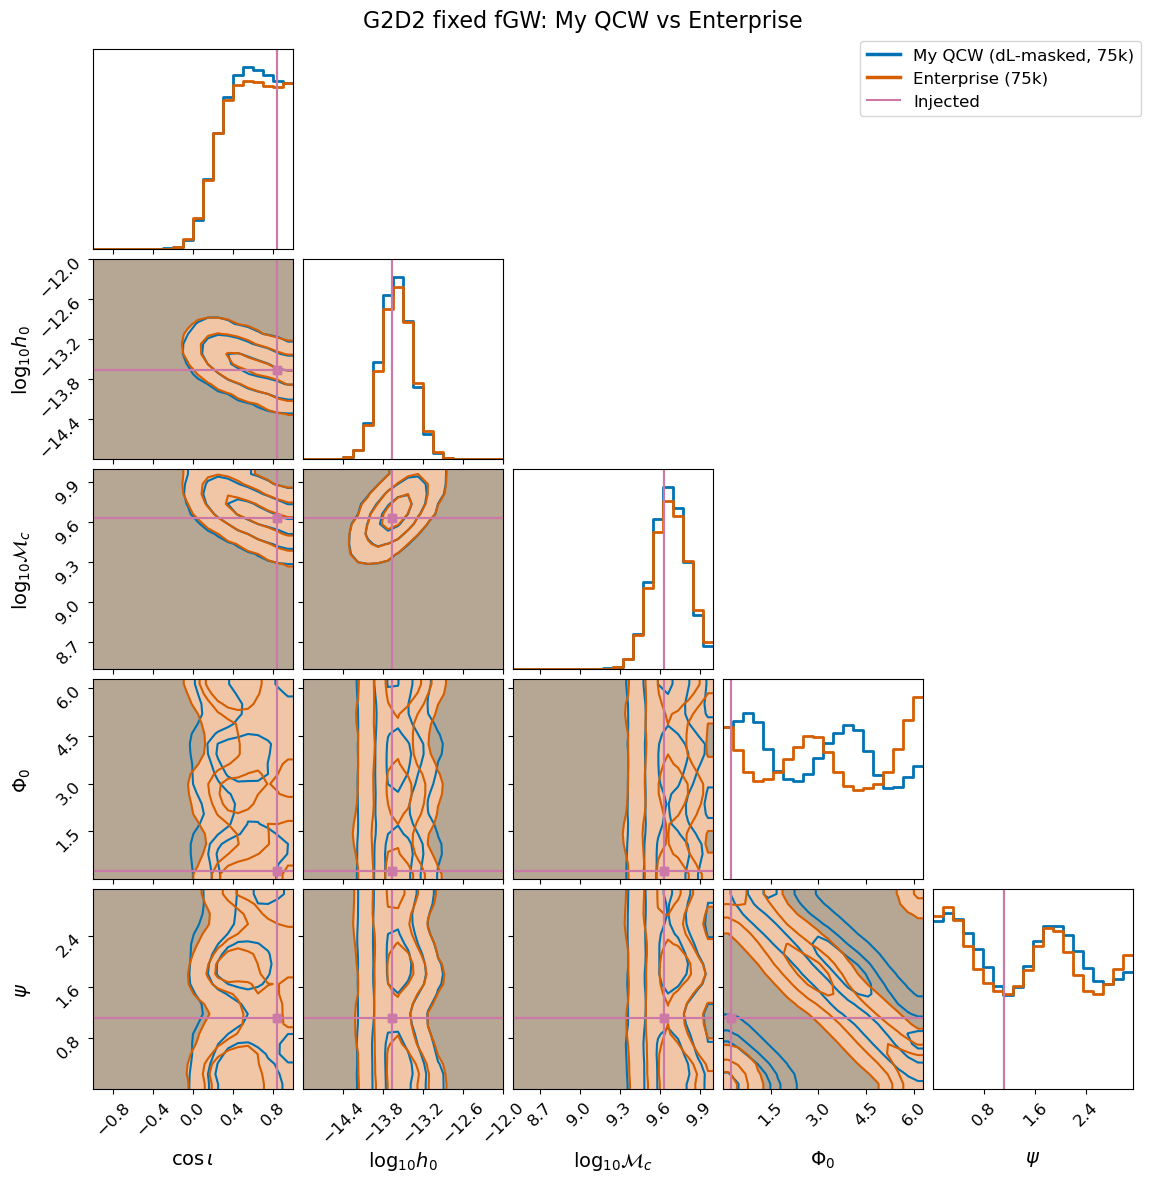

Panel 4: All three pipelines


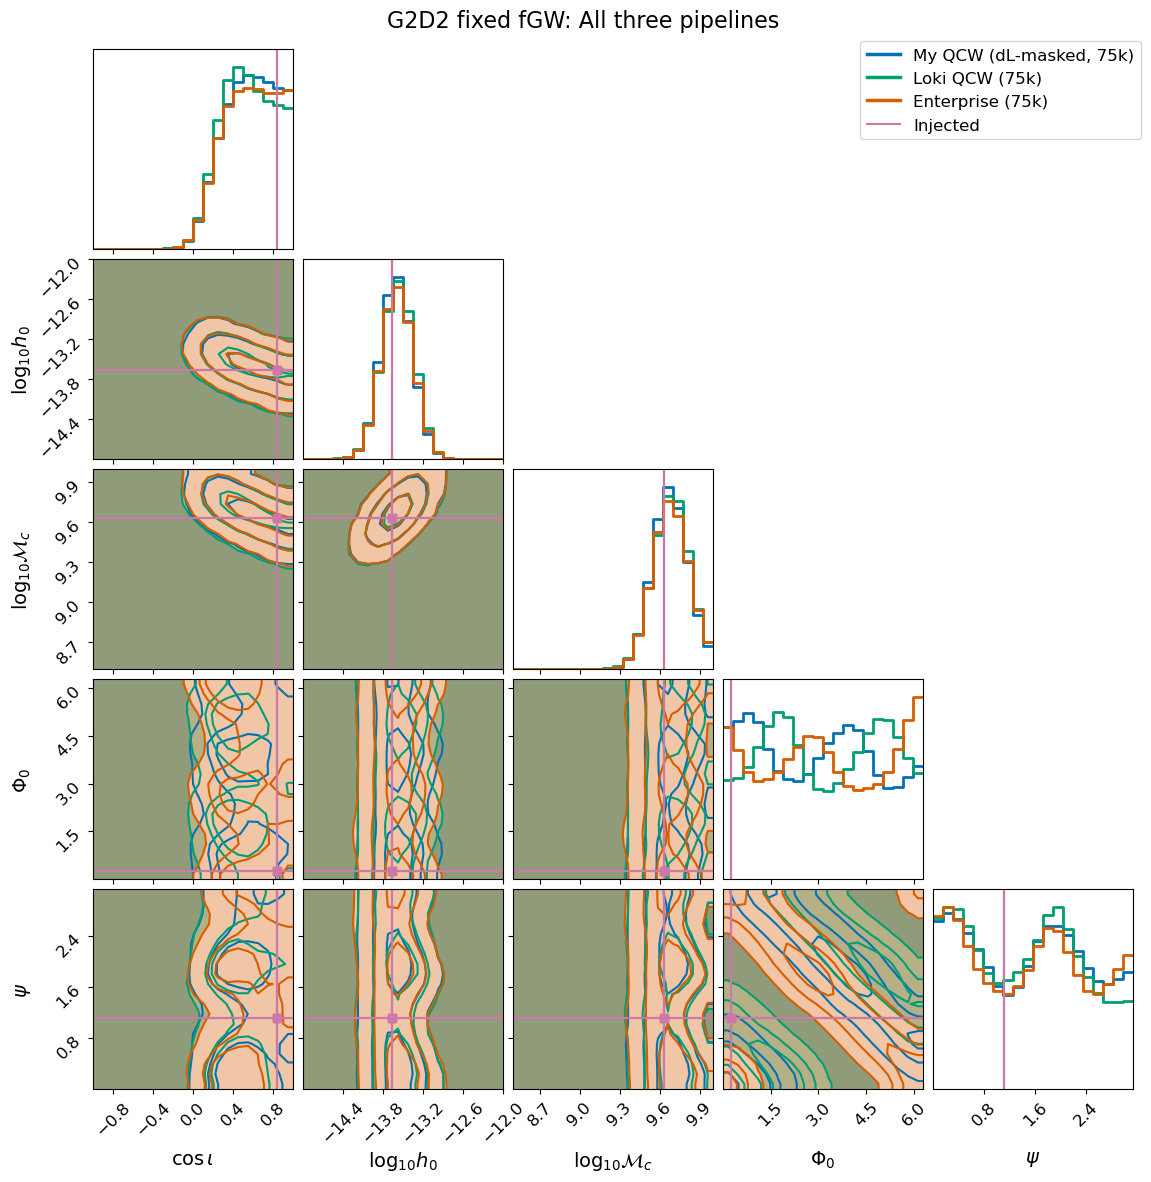


Savage-Dickey Bayes factors (FULL chains, no subsampling)
My QCW (n=126,372):     B10 = nan +/- nan


/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:262: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:222: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:254: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Loki   (n=1,000,000):     B10 = nan +/- nan
  Note: Loki log10_h0 derived; implicit prior on h0 is non-log-uniform.
Ent    (n=72,001):     B10 = nan +/- nan
  Note: Enterprise log10_h0 derived with fixed dL, fGW.


/usr/local/anaconda/lib/python3.9/site-packages/enterprise_extensions/model_utils.py:194: RuntimeWarning: divide by zero encountered in double_scalars
  bf.append(prior/post)


In [1]:
# ============================================================
# G2D2 fixed fGW Detection: comparison of three pipelines
# All three subsampled to 75k for corner plots
# SD BF computed from FULL chains
#
# 5x5 corner: cos_inc, log10_h0, log10_mc, Phi0, psi
#
# Pipelines:
#   - My QCW (dL-masked):  tref = MJD 53000 (phase0 shifted to lastTOA)
#   - Loki QCW (1M):       tref = last TOA (MJD 58175.6736)
#   - Bjorn Enterprise:    tref = last TOA (MJD 58175.6736)
# ============================================================

%matplotlib inline

import numpy as np
import h5py
import matplotlib.pyplot as plt
import corner
from enterprise_extensions import model_utils

plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 14

np.random.seed(42)


# ============================================================
# Constants and paths
# ============================================================
C_LIGHT = 299792458.0
MPC_IN_M = 3.085677581491367e22
T_SUN = 1.327124400e20 / C_LIGHT**3

LOG10_T_SUN = np.log10(T_SUN)
LOG10_PI = np.log10(np.pi)
LOG10_C = np.log10(C_LIGHT)
LOG10_MPC = np.log10(MPC_IN_M)
LOG10_2 = np.log10(2.0)

F_GW_FIXED = 3.7e-9
D_MPC_FIXED = 75.400

LOKI_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/"
    "G2D2_fixed_detect_loki_1M_lastTOA_22_May_2026.h5"
)
QCW_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "G2D2_narrow_detect_dLmasked_75.400Mpc.h5"
)
ENT_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/"
    "core_single_MDC2.h5"
)

N_SUBSAMPLE = 75000

# tref alignment
TREF_QCW_MJD = 53000.0
TREF_LASTTOA_MJD = 58175.6736349989
F_GW = 3.7e-9

DELTA_PHI0 = np.pi * F_GW * (TREF_LASTTOA_MJD - TREF_QCW_MJD) * 86400.0
print(f"Phase0 shift (My QCW -> last TOA tref): {DELTA_PHI0:.4f} rad")


# ============================================================
# Truth, labels, ranges
# ============================================================
truth = {
    "0_cos_inc":   0.8412486994612669,
    "0_log10_h":   -13.668773493298787,
    "0_log10_mc":  np.log10(4.3e9),
    "0_phase0":    0.24434609527920614,
    "0_psi":       1.1187560505283651,
}

qc_keys = ["0_cos_inc", "0_log10_h", "0_log10_mc", "0_phase0", "0_psi"]

labels = [
    r"$\cos\iota$",
    r"$\log_{10} h_0$",
    r"$\log_{10}\mathcal{M}_c$",
    r"$\Phi_0$",
    r"$\psi$",
]

ranges = [
    (-1, 1),
    (-15, -12),
    (8.5, 10.0),
    (0, 2*np.pi),
    (0, np.pi),
]


# ============================================================
# Log-space h0 derivation
# ============================================================
def derive_log10_h0(log10_mc, log10_fgw, log10_dL_Mpc):
    return (
        LOG10_2
        + (5.0/3.0) * (log10_mc + LOG10_T_SUN)
        + (2.0/3.0) * (LOG10_PI + log10_fgw)
        - (log10_dL_Mpc + LOG10_MPC - LOG10_C)
    )


# ============================================================
# Load Loki (1M, lastTOA tref)
# ============================================================
print("Loading Loki samples (1M, lastTOA tref)...")
with h5py.File(LOKI_FILE, "r") as f:
    loki_samples = f["samples_cold"][0, :, :]
    loki_par_names = [p.decode() if isinstance(p, bytes) else p
                      for p in f["par_names"][:]]

loki_log10_mc = loki_samples[:, loki_par_names.index("0_log10_mc")]
loki_log10_fgw = loki_samples[:, loki_par_names.index("0_log10_fgw")]
loki_log10_dist = loki_samples[:, loki_par_names.index("0_log10_dist")]
loki_log10_h0 = derive_log10_h0(loki_log10_mc, loki_log10_fgw, loki_log10_dist)

loki_plot_full = np.column_stack([
    loki_samples[:, loki_par_names.index("0_cos_inc")],
    loki_log10_h0,
    loki_log10_mc,
    loki_samples[:, loki_par_names.index("0_phase0")],
    loki_samples[:, loki_par_names.index("0_psi")],
])
print(f"  Loki (full): {loki_plot_full.shape}")

loki_sub = np.random.choice(loki_plot_full.shape[0], size=N_SUBSAMPLE, replace=False)
loki_plot = loki_plot_full[loki_sub]
print(f"  Loki (subsampled): {loki_plot.shape}")


# ============================================================
# Load my QCW (phase0 shifted to lastTOA tref)
# ============================================================
print("Loading my QCW dL-masked samples...")
with h5py.File(QCW_FILE, "r") as f:
    qc_samples = f["samples_masked"][...]
    qc_par_names = [p.decode() if isinstance(p, bytes) else p
                    for p in f["par_names"][:]]

qc_phase0_raw = qc_samples[:, qc_par_names.index("0_phase0")]
qc_phase0_shifted = (qc_phase0_raw + DELTA_PHI0) % (2 * np.pi)

qc_plot_full = np.column_stack([
    qc_samples[:, qc_par_names.index("0_cos_inc")],
    qc_samples[:, qc_par_names.index("0_log10_h")],
    qc_samples[:, qc_par_names.index("0_log10_mc")],
    qc_phase0_shifted,
    qc_samples[:, qc_par_names.index("0_psi")],
])
print(f"  My QCW (full): {qc_plot_full.shape}")

qc_sub = np.random.choice(qc_plot_full.shape[0], size=N_SUBSAMPLE, replace=False)
qc_plot = qc_plot_full[qc_sub]
print(f"  My QCW (subsampled): {qc_plot.shape}")


# ============================================================
# Load Enterprise (fixed fGW, dL fixed, lastTOA tref)
# ============================================================
print("Loading Enterprise samples...")
with h5py.File(ENT_FILE, "r") as f:
    e_samples_all = f["chain"][...]
    e_par_names = [p.decode() if isinstance(p, bytes) else p
                   for p in f["params"][:]]
    burn = f["metadata/burn"][()]
e_samples = e_samples_all[burn:, :]

ent_log10_mc = e_samples[:, e_par_names.index("log10_mc")]
ent_log10_h0 = derive_log10_h0(
    ent_log10_mc,
    np.full_like(ent_log10_mc, np.log10(F_GW_FIXED)),
    np.full_like(ent_log10_mc, np.log10(D_MPC_FIXED)),
)

ent_plot_full = np.column_stack([
    e_samples[:, e_par_names.index("cos_inc")],
    ent_log10_h0,
    ent_log10_mc,
    e_samples[:, e_par_names.index("phase0")],
    e_samples[:, e_par_names.index("psi")],
])
print(f"  Enterprise (full): {ent_plot_full.shape}")

ent_n = min(N_SUBSAMPLE, ent_plot_full.shape[0])
ent_sub = np.random.choice(ent_plot_full.shape[0], size=ent_n, replace=False)
ent_plot = ent_plot_full[ent_sub]
print(f"  Enterprise (subsampled): {ent_plot.shape}\n")


# ============================================================
# Plot styling
# ============================================================
C_QCW   = "#0072B2"
C_LOKI  = "#009E73"
C_ENT   = "#D55E00"
C_TRUTH = "#CC79A7"


def corner_kwargs(color):
    return dict(
        color=color,
        plot_datapoints=False,
        plot_density=False,
        fill_contours=True,
        smooth=1.0,
        smooth1d=1.0,
        levels=(0.393, 0.865, 0.989),
        hist_kwargs=dict(linewidth=2.0, color=color),
        contour_kwargs=dict(linewidths=1.5, colors=[color]),
        contourf_kwargs=dict(alpha=0.35, colors=[color]),
    )


def make_panel_corner(samples_list, colors_list, labels_pipelines, panel_title):
    truth_vals = [truth[k] for k in qc_keys]

    fig = corner.corner(
        samples_list[0],
        labels=labels,
        truths=truth_vals,
        truth_color=C_TRUTH,
        range=ranges,
        show_titles=False,
        label_kwargs={"fontsize": 14},
        **corner_kwargs(colors_list[0]),
    )

    for samples, color in zip(samples_list[1:], colors_list[1:]):
        corner.corner(
            samples,
            fig=fig,
            labels=labels,
            truths=truth_vals,
            truth_color=C_TRUTH,
            range=ranges,
            show_titles=False,
            **corner_kwargs(color),
        )

    for ax in fig.get_axes():
        ax.tick_params(axis="both", labelsize=12)

    handles = [plt.Line2D([0], [0], color=c, lw=2.5, label=lab)
               for c, lab in zip(colors_list, labels_pipelines)]
    handles.append(plt.Line2D([0], [0], color=C_TRUTH, lw=1.5, label="Injected"))
    fig.legend(handles=handles, loc="upper right", fontsize=12,
               bbox_to_anchor=(0.98, 0.98), frameon=True)

    fig.suptitle(panel_title, fontsize=16, y=1.0)
    return fig


# ============================================================
# Generate four panels
# ============================================================
print("Panel 1: My QCW vs Loki")
fig1 = make_panel_corner(
    [qc_plot, loki_plot],
    [C_QCW, C_LOKI],
    ["My QCW (dL-masked, 75k)", "Loki QCW (75k)"],
    "G2D2 fixed fGW: My QCW vs Loki QCW",
)
plt.show()

print("Panel 2: Loki vs Enterprise")
fig2 = make_panel_corner(
    [loki_plot, ent_plot],
    [C_LOKI, C_ENT],
    ["Loki QCW (75k), subsampled from 1M", "Enterprise (75k)"],
    "G2D2 fixed fGW: Loki QCW vs Enterprise",
)
plt.show()

print("Panel 3: My QCW vs Enterprise")
fig3 = make_panel_corner(
    [qc_plot, ent_plot],
    [C_QCW, C_ENT],
    ["My QCW (dL-masked, 75k)", "Enterprise (75k)"],
    "G2D2 fixed fGW: My QCW vs Enterprise",
)
plt.show()

print("Panel 4: All three pipelines")
fig4 = make_panel_corner(
    [qc_plot, loki_plot, ent_plot],
    [C_QCW, C_LOKI, C_ENT],
    ["My QCW (dL-masked, 75k)", "Loki QCW (75k)", "Enterprise (75k)"],
    "G2D2 fixed fGW: All three pipelines",
)
plt.show()


# ============================================================
# SD Bayes factors using FULL chains
# ============================================================
print("\n" + "="*60)
print("Savage-Dickey Bayes factors (FULL chains, no subsampling)")
print("="*60)

qcw_BF, qcw_BF_err = model_utils.bayes_fac(
    samples=qc_plot_full[:, qc_keys.index("0_log10_h")], logAmax=-11)
print(f"My QCW (n={qc_plot_full.shape[0]:,}):     B10 = {qcw_BF:.4f} +/- {qcw_BF_err:.4f}")

loki_BF, loki_BF_err = model_utils.bayes_fac(
    samples=loki_plot_full[:, qc_keys.index("0_log10_h")], logAmax=-11)
print(f"Loki   (n={loki_plot_full.shape[0]:,}):     B10 = {loki_BF:.4f} +/- {loki_BF_err:.4f}")
print("  Note: Loki log10_h0 derived; implicit prior on h0 is non-log-uniform.")

ent_BF, ent_BF_err = model_utils.bayes_fac(
    samples=ent_plot_full[:, qc_keys.index("0_log10_h")], logAmax=-11)
print(f"Ent    (n={ent_plot_full.shape[0]:,}):     B10 = {ent_BF:.4f} +/- {ent_BF_err:.4f}")
print("  Note: Enterprise log10_h0 derived with fixed dL, fGW.")

Loading my QCW...
  Using QCW GWB column: gwb_log10_A
Loading Loki...
  Using Loki GWB column: gwb_log10_A
Loading Enterprise...
  Using Ent GWB column: crn_log10_A

Chain lengths: My QCW = 126,372, Loki = 1,000,000, Ent = 72,001


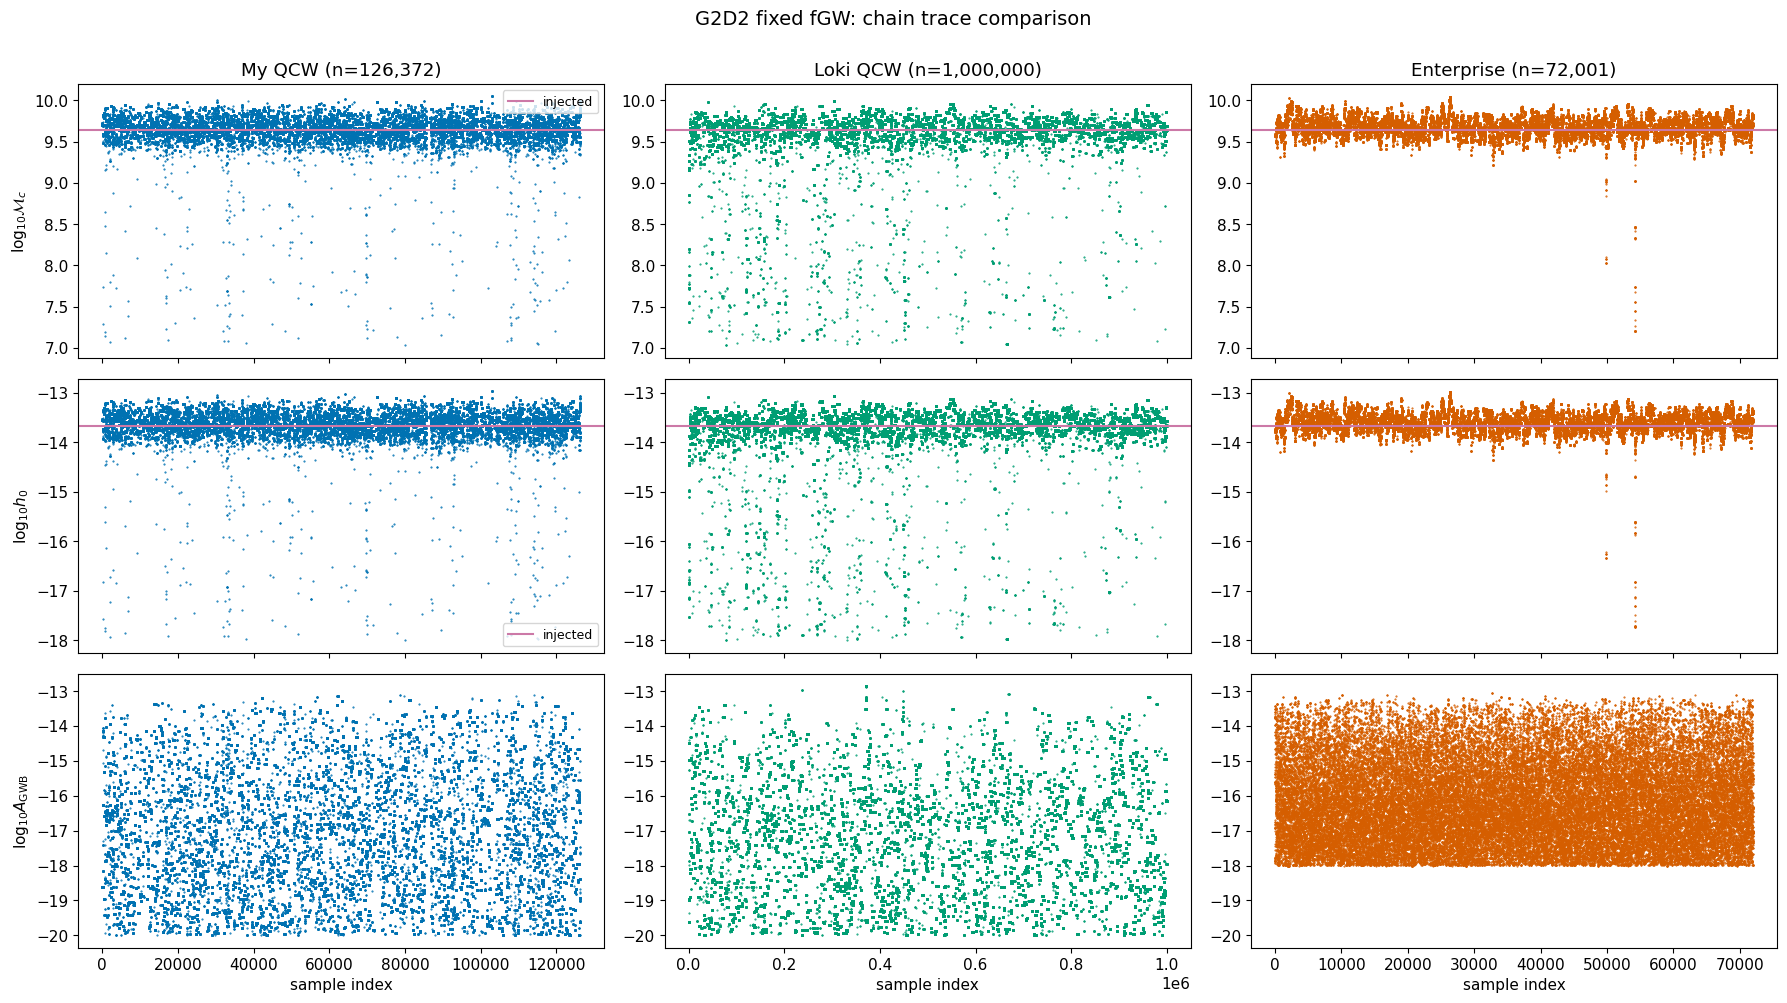


Mode switching summary (fixed fGW)

My QCW:
  Samples with Mc < 8:                    115 (0.09%)
  Samples at h0 floor (log10_h0 < -17.9): 9 (0.007%)

Loki:
  Samples with Mc < 8:                    1114 (0.11%)
  Samples at h0 floor (log10_h0 < -17.9): 99 (0.010%)

Enterprise:
  Samples with Mc < 8:                    23 (0.03%)
  Samples at h0 floor (log10_h0 < -17.9): 0 (0.000%)


In [2]:
# ============================================================
# G2D2 fixed fGW: Trace plot comparison across three pipelines
# 3 rows: log10_Mc, log10_h0, log10_A_GWB
# 3 columns: My QCW, Loki QCW (1M lastTOA), Enterprise
# All traces use dot markers
# ============================================================

%matplotlib inline
import numpy as np
import h5py
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11


# ============================================================
# Constants and paths
# ============================================================
C_LIGHT = 299792458.0
MPC_IN_M = 3.085677581491367e22
T_SUN = 1.327124400e20 / C_LIGHT**3
LOG10_T_SUN = np.log10(T_SUN)
LOG10_PI    = np.log10(np.pi)
LOG10_C     = np.log10(C_LIGHT)
LOG10_MPC   = np.log10(MPC_IN_M)
LOG10_2     = np.log10(2.0)

F_GW_FIXED = 3.7e-9
D_MPC_FIXED = 75.400

LOKI_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/"
    "G2D2_fixed_detect_loki_1M_lastTOA_22_May_2026.h5"
)
QCW_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "G2D2_narrow_detect_dLmasked_75.400Mpc.h5"
)
ENT_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/"
    "core_single_MDC2.h5"
)


def derive_log10_h0(log10_mc, log10_fgw, log10_dL_Mpc):
    return (LOG10_2
            + (5.0 / 3.0) * (log10_mc + LOG10_T_SUN)
            + (2.0 / 3.0) * (LOG10_PI + log10_fgw)
            - (log10_dL_Mpc + LOG10_MPC - LOG10_C))


truth_mc = np.log10(4.3e9)
truth_h0 = -13.668773

C_QCW   = "#0072B2"
C_LOKI  = "#009E73"
C_ENT   = "#D55E00"
C_TRUTH = "#CC79A7"


# ============================================================
# Load my QCW
# ============================================================
print("Loading my QCW...")
with h5py.File(QCW_FILE, "r") as f:
    qc    = f["samples_masked"][...]
    qc_pn = [p.decode() if isinstance(p, bytes) else p for p in f["par_names"][:]]

qcw_mc = qc[:, qc_pn.index("0_log10_mc")]
qcw_h  = qc[:, qc_pn.index("0_log10_h")]

qcw_gwb = None
for candidate in ["gwb_log10_A", "gw_log10_A", "log10_A_gw", "crn_log10_A"]:
    if candidate in qc_pn:
        qcw_gwb = qc[:, qc_pn.index(candidate)]
        print(f"  Using QCW GWB column: {candidate}")
        break
if qcw_gwb is None:
    gwb_candidates = [p for p in qc_pn if "gwb" in p.lower() or "gw_" in p.lower()]
    if gwb_candidates:
        qcw_gwb = qc[:, qc_pn.index(gwb_candidates[0])]
        print(f"  Falling back to: {gwb_candidates[0]}")


# ============================================================
# Load Loki QCW (1M, lastTOA tref)
# ============================================================
print("Loading Loki...")
with h5py.File(LOKI_FILE, "r") as f:
    lk    = f["samples_cold"][0, :, :]
    lk_pn = [p.decode() if isinstance(p, bytes) else p for p in f["par_names"][:]]

loki_mc   = lk[:, lk_pn.index("0_log10_mc")]
loki_fgw  = lk[:, lk_pn.index("0_log10_fgw")]
loki_dist = lk[:, lk_pn.index("0_log10_dist")]
loki_h    = derive_log10_h0(loki_mc, loki_fgw, loki_dist)

loki_gwb = None
for candidate in ["gwb_log10_A", "gw_log10_A", "log10_A_gw", "crn_log10_A"]:
    if candidate in lk_pn:
        loki_gwb = lk[:, lk_pn.index(candidate)]
        print(f"  Using Loki GWB column: {candidate}")
        break
if loki_gwb is None:
    gwb_candidates = [p for p in lk_pn if "gwb" in p.lower() or "gw_" in p.lower()]
    if gwb_candidates:
        loki_gwb = lk[:, lk_pn.index(gwb_candidates[0])]
        print(f"  Falling back to: {gwb_candidates[0]}")


# ============================================================
# Load Enterprise
# ============================================================
print("Loading Enterprise...")
with h5py.File(ENT_FILE, "r") as f:
    en    = f["chain"][...]
    en_pn = [p.decode() if isinstance(p, bytes) else p for p in f["params"][:]]
    burn  = f["metadata/burn"][()]
en = en[burn:, :]

ent_mc = en[:, en_pn.index("log10_mc")]
ent_h  = derive_log10_h0(
    ent_mc,
    np.full_like(ent_mc, np.log10(F_GW_FIXED)),
    np.full_like(ent_mc, np.log10(D_MPC_FIXED))
)

ent_gwb = None
for candidate in ["crn_log10_A", "gwb_log10_A", "gw_log10_A"]:
    if candidate in en_pn:
        ent_gwb = en[:, en_pn.index(candidate)]
        print(f"  Using Ent GWB column: {candidate}")
        break

print(f"\nChain lengths: My QCW = {len(qcw_mc):,}, Loki = {len(loki_mc):,}, Ent = {len(ent_mc):,}")


# ============================================================
# 3 rows x 3 columns trace plot (dot markers)
# ============================================================
DOT = dict(marker=".", linestyle="None", markersize=1, rasterized=True)

n_rows = 3
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 10), sharex="col")

# Row 0: log10_Mc
axes[0, 0].plot(qcw_mc, color=C_QCW, **DOT)
axes[0, 0].axhline(truth_mc, color=C_TRUTH, lw=1.5, label="injected")
axes[0, 0].set_ylabel(r"$\log_{10}\mathcal{M}_c$")
axes[0, 0].set_title(f"My QCW (n={len(qcw_mc):,})")
axes[0, 0].legend(loc="upper right", fontsize=9)

axes[0, 1].plot(loki_mc, color=C_LOKI, **DOT)
axes[0, 1].axhline(truth_mc, color=C_TRUTH, lw=1.5)
axes[0, 1].set_title(f"Loki QCW (n={len(loki_mc):,})")

axes[0, 2].plot(ent_mc, color=C_ENT, **DOT)
axes[0, 2].axhline(truth_mc, color=C_TRUTH, lw=1.5)
axes[0, 2].set_title(f"Enterprise (n={len(ent_mc):,})")

# Row 1: log10_h0
axes[1, 0].plot(qcw_h, color=C_QCW, **DOT)
axes[1, 0].axhline(truth_h0, color=C_TRUTH, lw=1.5, label="injected")
axes[1, 0].set_ylabel(r"$\log_{10}h_0$")
axes[1, 0].legend(loc="lower right", fontsize=9)

axes[1, 1].plot(loki_h, color=C_LOKI, **DOT)
axes[1, 1].axhline(truth_h0, color=C_TRUTH, lw=1.5)

axes[1, 2].plot(ent_h, color=C_ENT, **DOT)
axes[1, 2].axhline(truth_h0, color=C_TRUTH, lw=1.5)

# Row 2: log10_A_GWB
if qcw_gwb is not None:
    axes[2, 0].plot(qcw_gwb, color=C_QCW, **DOT)
else:
    axes[2, 0].text(0.5, 0.5, "GWB not found", transform=axes[2, 0].transAxes,
                    ha="center", va="center")
axes[2, 0].set_ylabel(r"$\log_{10}A_{\rm GWB}$")
axes[2, 0].set_xlabel("sample index")

if loki_gwb is not None:
    axes[2, 1].plot(loki_gwb, color=C_LOKI, **DOT)
else:
    axes[2, 1].text(0.5, 0.5, "GWB not found", transform=axes[2, 1].transAxes,
                    ha="center", va="center")
axes[2, 1].set_xlabel("sample index")

if ent_gwb is not None:
    axes[2, 2].plot(ent_gwb, color=C_ENT, **DOT)
else:
    axes[2, 2].text(0.5, 0.5, "GWB not found", transform=axes[2, 2].transAxes,
                    ha="center", va="center")
axes[2, 2].set_xlabel("sample index")

# Match y-axis ranges across columns
for row in range(n_rows):
    ymins, ymaxs = [], []
    for col in range(3):
        yl, yh = axes[row, col].get_ylim()
        ymins.append(yl)
        ymaxs.append(yh)
    ymin, ymax = min(ymins), max(ymaxs)
    for col in range(3):
        axes[row, col].set_ylim(ymin, ymax)

plt.suptitle("G2D2 fixed fGW: chain trace comparison", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()


# ============================================================
# Mode switching summary
# ============================================================
print("\n" + "=" * 70)
print("Mode switching summary (fixed fGW)")
print("=" * 70)

for name, mc, h in [
    ("My QCW",     qcw_mc,  qcw_h),
    ("Loki",       loki_mc, loki_h),
    ("Enterprise", ent_mc,  ent_h),
]:
    h_at_floor = h < -17.9
    mc_low     = mc < 8
    print(f"\n{name}:")
    print(f"  Samples with Mc < 8:                    "
          f"{mc_low.sum()} ({100 * mc_low.mean():.2f}%)")
    print(f"  Samples at h0 floor (log10_h0 < -17.9): "
          f"{h_at_floor.sum()} ({100 * h_at_floor.mean():.3f}%)")

In [3]:
# ============================================================
# G2D2 fixed fGW: Effective Sample Size calculation
# Three pipelines: My QCW, Loki (1M lastTOA), Enterprise
# Mc is the only shape parameter that varies (fGW and dL fixed)
# ============================================================

%matplotlib inline
import numpy as np
import h5py
from emcee import autocorr


# ============================================================
# Constants
# ============================================================
C_LIGHT = 299792458.0
MPC_IN_M = 3.085677581491367e22
T_SUN = 1.327124400e20 / C_LIGHT**3
LOG10_T_SUN = np.log10(T_SUN)
LOG10_PI    = np.log10(np.pi)
LOG10_C     = np.log10(C_LIGHT)
LOG10_MPC   = np.log10(MPC_IN_M)
LOG10_2     = np.log10(2.0)

F_GW_FIXED = 3.7e-9
D_MPC_FIXED = 75.400

LOKI_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/"
    "G2D2_fixed_detect_loki_1M_lastTOA_22_May_2026.h5"
)
QCW_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "G2D2_narrow_detect_dLmasked_75.400Mpc.h5"
)
ENT_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/"
    "core_single_MDC2.h5"
)


def derive_log10_h0(log10_mc, log10_fgw, log10_dL_Mpc):
    return (LOG10_2
            + (5.0 / 3.0) * (log10_mc + LOG10_T_SUN)
            + (2.0 / 3.0) * (LOG10_PI + log10_fgw)
            - (log10_dL_Mpc + LOG10_MPC - LOG10_C))


def compute_ess(samples):
    try:
        tau = autocorr.integrated_time(samples, quiet=True)[0]
        ess = len(samples) / tau
        return tau, ess
    except Exception as e:
        print(f"    autocorr failed: {e}")
        return np.nan, np.nan


# ============================================================
# Load all chains
# ============================================================
print("Loading my QCW...")
with h5py.File(QCW_FILE, "r") as f:
    qc = f["samples_masked"][...]
    qc_pn = [p.decode() if isinstance(p, bytes) else p for p in f["par_names"][:]]
qcw_mc = qc[:, qc_pn.index("0_log10_mc")]
qcw_h  = qc[:, qc_pn.index("0_log10_h")]

print("Loading Loki...")
with h5py.File(LOKI_FILE, "r") as f:
    lk = f["samples_cold"][0, :, :]
    lk_pn = [p.decode() if isinstance(p, bytes) else p for p in f["par_names"][:]]
loki_mc   = lk[:, lk_pn.index("0_log10_mc")]
loki_fgw  = lk[:, lk_pn.index("0_log10_fgw")]
loki_dist = lk[:, lk_pn.index("0_log10_dist")]
loki_h    = derive_log10_h0(loki_mc, loki_fgw, loki_dist)

print("Loading Enterprise...")
with h5py.File(ENT_FILE, "r") as f:
    en = f["chain"][...]
    en_pn = [p.decode() if isinstance(p, bytes) else p for p in f["params"][:]]
    burn = f["metadata/burn"][()]
en = en[burn:, :]
ent_mc = en[:, en_pn.index("log10_mc")]
ent_h  = derive_log10_h0(
    ent_mc,
    np.full_like(ent_mc, np.log10(F_GW_FIXED)),
    np.full_like(ent_mc, np.log10(D_MPC_FIXED))
)

print(f"\nChain lengths: My QCW = {len(qcw_mc):,}, Loki = {len(loki_mc):,}, Ent = {len(ent_mc):,}")


# ============================================================
# ESS table
# ============================================================
print("\n" + "=" * 70)
print("Effective Sample Size: G2D2 fixed fGW")
print("=" * 70)
print(f"{'Pipeline':<15} {'Param':<12} {'N raw':<12} {'tau':<10} {'ESS':<10}")
print("-" * 70)

for pipe_name, mc, h in [
    ("My QCW",     qcw_mc, qcw_h),
    ("Loki",       loki_mc, loki_h),
    ("Enterprise", ent_mc, ent_h),
]:
    tau_mc, ess_mc = compute_ess(mc)
    tau_h,  ess_h  = compute_ess(h)
    print(f"{pipe_name:<15} {'log10_Mc':<12} {len(mc):<12,} {tau_mc:<10.1f} {ess_mc:<10.0f}")
    print(f"{pipe_name:<15} {'log10_h0':<12} {len(h):<12,} {tau_h:<10.1f} {ess_h:<10.0f}")
    print()

print("=" * 70)
print("Mc is the only shape parameter that varies (fGW and dL are fixed).")
print("ESS > 1000 = well sampled; ESS < 100 = poor mixing.")

from emcee.autocorr import integrated_time

tau_phase0 = integrated_time(chain[:, idx_phase0], quiet=True)
tau_psi = integrated_time(chain[:, idx_psi], quiet=True)

ess_phase0 = len(chain) / tau_phase0
ess_psi = len(chain) / tau_psi

Loading my QCW...
Loading Loki...
Loading Enterprise...

Chain lengths: My QCW = 126,372, Loki = 1,000,000, Ent = 72,001

Effective Sample Size: G2D2 fixed fGW
Pipeline        Param        N raw        tau        ESS       
----------------------------------------------------------------------
My QCW          log10_Mc     126,372      54.8       2304      
My QCW          log10_h0     126,372      54.9       2303      

Loki            log10_Mc     1,000,000    3171.7     315       
Loki            log10_h0     1,000,000    3170.8     315       

Enterprise      log10_Mc     72,001       185.8      387       
Enterprise      log10_h0     72,001       185.8      387       

Mc is the only shape parameter that varies (fGW and dL are fixed).
ESS > 1000 = well sampled; ESS < 100 = poor mixing.


NameError: name 'chain' is not defined

In [ ]:
# ============================================================
# ESS for all CW extrinsic parameters
# ============================================================
print("\n" + "=" * 70)
print("ESS: phase0, psi, log10_Mc, log10_h0")
print("=" * 70)
print(f"{'Pipeline':<15} {'Param':<12} {'N raw':<12} {'tau':<10} {'ESS':<10}")
print("-" * 70)

# My QCW
qcw_phase0 = qc[:, qc_pn.index("0_phase0")]
qcw_psi    = qc[:, qc_pn.index("0_psi")]

# Loki
loki_phase0 = lk[:, lk_pn.index("0_phase0")]
loki_psi    = lk[:, lk_pn.index("0_psi")]

# Enterprise
ent_phase0 = en[:, en_pn.index("phase0")]
ent_psi    = en[:, en_pn.index("psi")]

for pipe_name, phase0, psi, mc, h in [
    ("My QCW",     qcw_phase0, qcw_psi, qcw_mc, qcw_h),
    ("Loki",       loki_phase0, loki_psi, loki_mc, loki_h),
    ("Enterprise", ent_phase0, ent_psi, ent_mc, ent_h),
]:
    for par_name, samples in [
        ("log10_Mc", mc),
        ("log10_h0", h),
        ("phase0",   phase0),
        ("psi",      psi),
    ]:
        tau, ess = compute_ess(samples)
        print(f"{pipe_name:<15} {par_name:<12} {len(samples):<12,} {tau:<10.1f} {ess:<10.0f}")
    print()

Loading my QCW...
  All GWB/gamma params: ['J0030+0451_red_noise_gamma', 'J0034-0534_red_noise_gamma', 'J0218+4232_red_noise_gamma', 'J0437-4715_red_noise_gamma', 'J0613-0200_red_noise_gamma', 'J0621+1002_red_noise_gamma', 'J0711-6830_red_noise_gamma', 'J0751+1807_red_noise_gamma', 'J0900-3144_red_noise_gamma', 'J1012+5307_red_noise_gamma', 'J1022+1001_red_noise_gamma', 'J1024-0719_red_noise_gamma', 'J1045-4509_red_noise_gamma', 'J1455-3330_red_noise_gamma', 'J1600-3053_red_noise_gamma', 'J1603-7202_red_noise_gamma', 'J1614-2230_red_noise_gamma', 'J1640+2224_red_noise_gamma', 'J1643-1224_red_noise_gamma', 'J1713+0747_red_noise_gamma', 'J1730-2304_red_noise_gamma', 'J1744-1134_red_noise_gamma', 'J1857+0943_red_noise_gamma', 'J1909-3744_red_noise_gamma', 'J1918-0642_red_noise_gamma', 'J1939+2134_red_noise_gamma', 'J1944+0907_red_noise_gamma', 'J2010-1323_red_noise_gamma', 'J2124-3358_red_noise_gamma', 'J2129-5721_red_noise_gamma', 'J2145-0750_red_noise_gamma', 'J2229+2643_red_noise_gamma

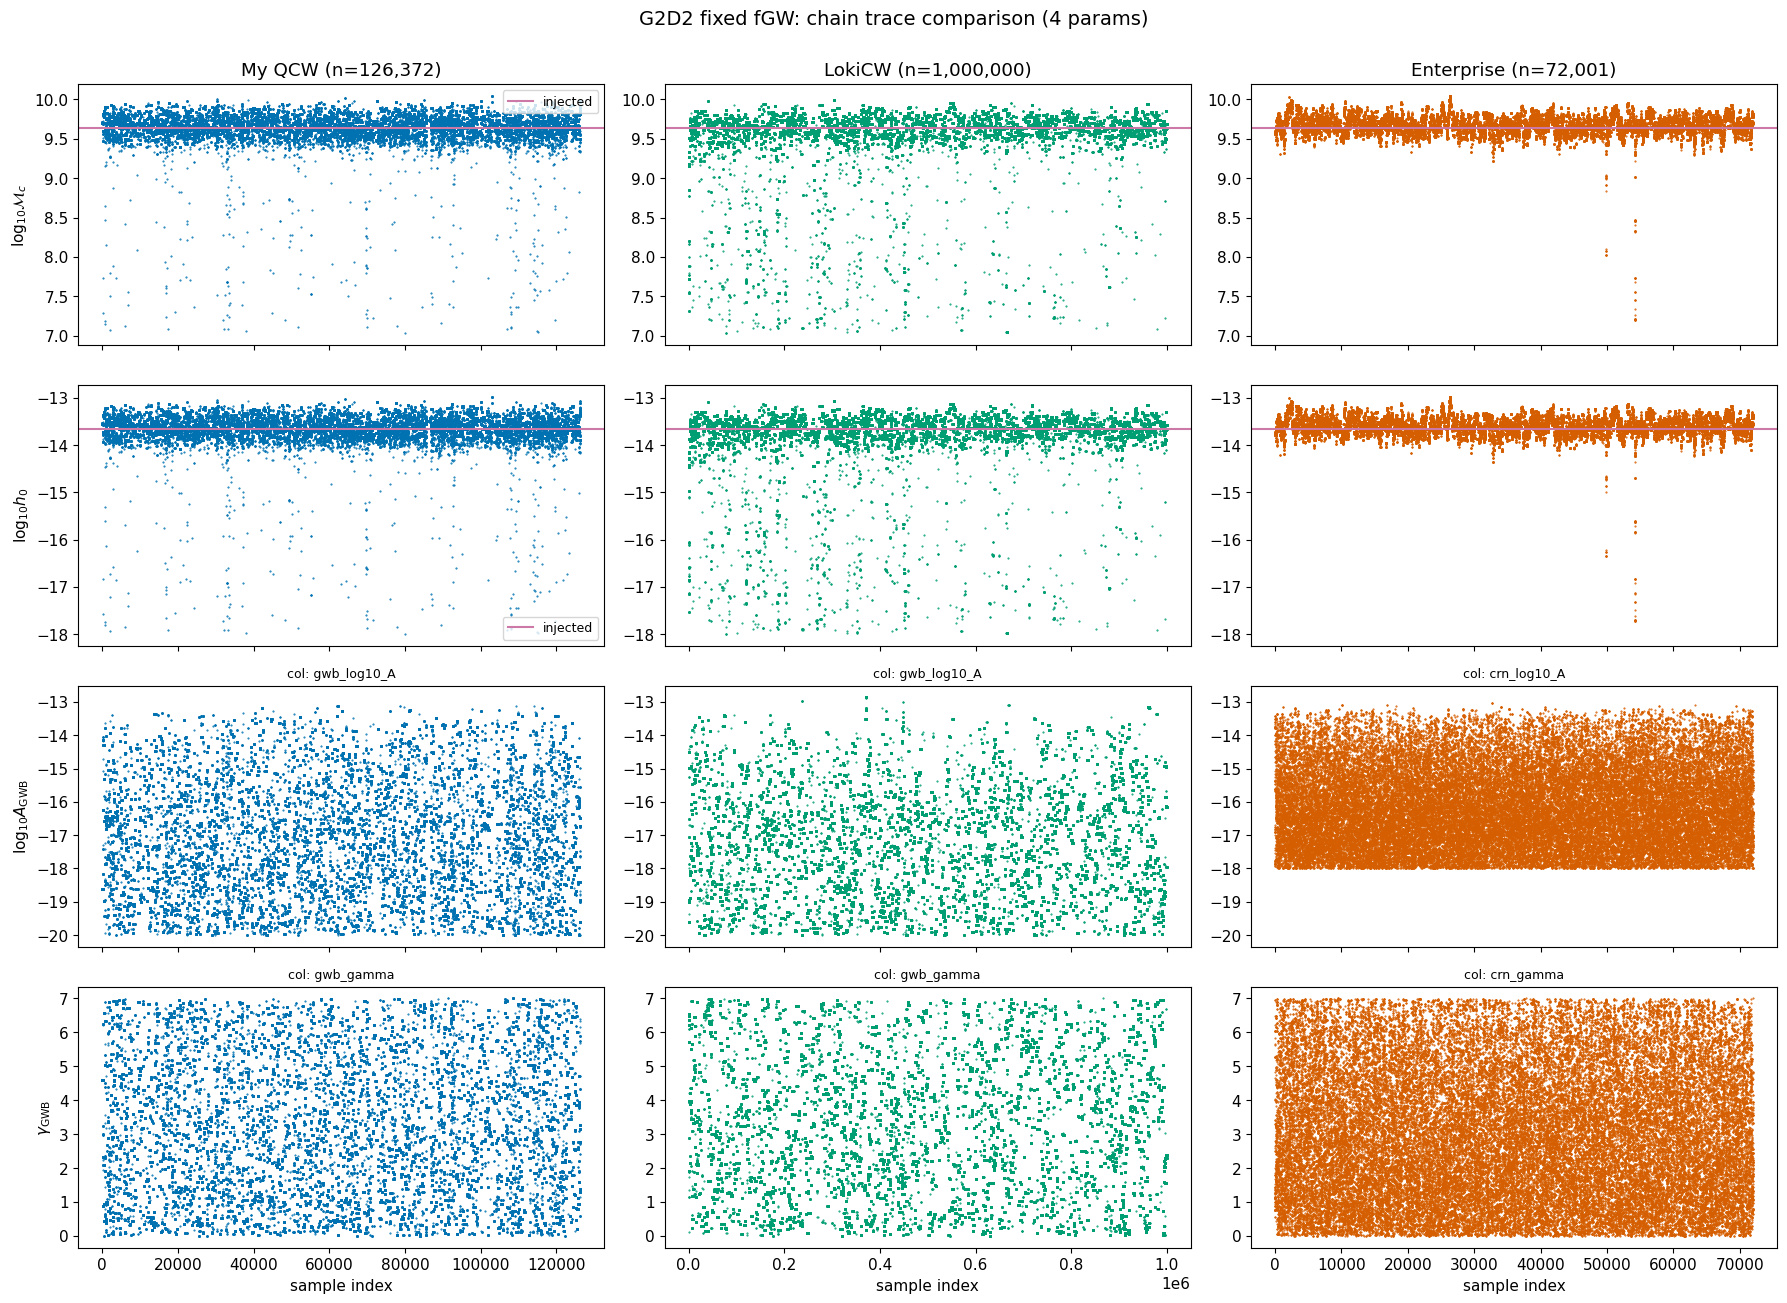


Mode switching summary (fixed fGW)

My QCW:
  Samples with Mc < 8:                    115 (0.09%)
  Samples at h0 floor (log10_h0 < -17.9): 9 (0.007%)

LokiCW:
  Samples with Mc < 8:                    1114 (0.11%)
  Samples at h0 floor (log10_h0 < -17.9): 99 (0.010%)

Enterprise:
  Samples with Mc < 8:                    23 (0.03%)
  Samples at h0 floor (log10_h0 < -17.9): 0 (0.000%)


In [4]:
# ============================================================
# G2D2 fixed fGW: Trace plot comparison across three pipelines
# 4 rows: log10_Mc, log10_h0, log10_A_GWB, gamma_GWB
# 3 columns: My QCW, LokiCW (1M lastTOA), Enterprise
# Prints all GWB-related parameter names from each file
# ============================================================

%matplotlib inline
import numpy as np
import h5py
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11


# ============================================================
# Constants and paths
# ============================================================
C_LIGHT = 299792458.0
MPC_IN_M = 3.085677581491367e22
T_SUN = 1.327124400e20 / C_LIGHT**3
LOG10_T_SUN = np.log10(T_SUN)
LOG10_PI    = np.log10(np.pi)
LOG10_C     = np.log10(C_LIGHT)
LOG10_MPC   = np.log10(MPC_IN_M)
LOG10_2     = np.log10(2.0)

F_GW_FIXED = 3.7e-9
D_MPC_FIXED = 75.400

LOKI_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/"
    "G2D2_fixed_detect_loki_1M_lastTOA_22_May_2026.h5"
)
QCW_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "G2D2_narrow_detect_dLmasked_75.400Mpc.h5"
)
ENT_FILE = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/"
    "core_single_MDC2.h5"
)


def derive_log10_h0(log10_mc, log10_fgw, log10_dL_Mpc):
    return (LOG10_2
            + (5.0 / 3.0) * (log10_mc + LOG10_T_SUN)
            + (2.0 / 3.0) * (LOG10_PI + log10_fgw)
            - (log10_dL_Mpc + LOG10_MPC - LOG10_C))


def find_column(par_names, candidates, label=""):
    """Search par_names for the first match in candidates. Print result."""
    for c in candidates:
        if c in par_names:
            print(f"  {label}: found '{c}'")
            return c
    print(f"  {label}: NOT FOUND (tried {candidates})")
    return None


truth_mc = np.log10(4.3e9)
truth_h0 = -13.668773

C_QCW   = "#0072B2"
C_LOKI  = "#009E73"
C_ENT   = "#D55E00"
C_TRUTH = "#CC79A7"


# ============================================================
# Load my QCW
# ============================================================
print("=" * 70)
print("Loading my QCW...")
with h5py.File(QCW_FILE, "r") as f:
    qc    = f["samples_masked"][...]
    qc_pn = [p.decode() if isinstance(p, bytes) else p for p in f["par_names"][:]]

# Print all GWB/CRN related params
qc_gwb_params = [p for p in qc_pn if any(k in p.lower() for k in ["gwb", "gw_", "crn", "gamma"])]
print(f"  All GWB/gamma params: {qc_gwb_params}")

qcw_mc = qc[:, qc_pn.index("0_log10_mc")]
qcw_h  = qc[:, qc_pn.index("0_log10_h")]

gwb_A_candidates   = ["gwb_log10_A", "gw_log10_A", "log10_A_gw", "crn_log10_A"]
gwb_gam_candidates = ["gwb_gamma", "gw_gamma", "gamma_gw", "crn_gamma"]

qcw_gwb_name = find_column(qc_pn, gwb_A_candidates, "QCW A_GWB")
qcw_gam_name = find_column(qc_pn, gwb_gam_candidates, "QCW gamma_GWB")

qcw_gwb = qc[:, qc_pn.index(qcw_gwb_name)] if qcw_gwb_name else None
qcw_gam = qc[:, qc_pn.index(qcw_gam_name)] if qcw_gam_name else None


# ============================================================
# Load LokiCW (1M, lastTOA tref)
# ============================================================
print("\n" + "=" * 70)
print("Loading LokiCW...")
with h5py.File(LOKI_FILE, "r") as f:
    lk    = f["samples_cold"][0, :, :]
    lk_pn = [p.decode() if isinstance(p, bytes) else p for p in f["par_names"][:]]

lk_gwb_params = [p for p in lk_pn if any(k in p.lower() for k in ["gwb", "gw_", "crn", "gamma"])]
print(f"  All GWB/gamma params: {lk_gwb_params}")

loki_mc   = lk[:, lk_pn.index("0_log10_mc")]
loki_fgw  = lk[:, lk_pn.index("0_log10_fgw")]
loki_dist = lk[:, lk_pn.index("0_log10_dist")]
loki_h    = derive_log10_h0(loki_mc, loki_fgw, loki_dist)

loki_gwb_name = find_column(lk_pn, gwb_A_candidates, "LokiCW A_GWB")
loki_gam_name = find_column(lk_pn, gwb_gam_candidates, "LokiCW gamma_GWB")

loki_gwb = lk[:, lk_pn.index(loki_gwb_name)] if loki_gwb_name else None
loki_gam = lk[:, lk_pn.index(loki_gam_name)] if loki_gam_name else None


# ============================================================
# Load Enterprise
# ============================================================
print("\n" + "=" * 70)
print("Loading Enterprise...")
with h5py.File(ENT_FILE, "r") as f:
    en    = f["chain"][...]
    en_pn = [p.decode() if isinstance(p, bytes) else p for p in f["params"][:]]
    burn  = f["metadata/burn"][()]
en = en[burn:, :]

en_gwb_params = [p for p in en_pn if any(k in p.lower() for k in ["gwb", "gw_", "crn", "gamma"])]
print(f"  All GWB/gamma params: {en_gwb_params}")

ent_mc = en[:, en_pn.index("log10_mc")]
ent_h  = derive_log10_h0(
    ent_mc,
    np.full_like(ent_mc, np.log10(F_GW_FIXED)),
    np.full_like(ent_mc, np.log10(D_MPC_FIXED))
)

# Enterprise may use crn_ or gw_ or gwb_ prefix
ent_gwb_name = find_column(en_pn, ["crn_log10_A", "gwb_log10_A", "gw_log10_A"], "Ent A_GWB")
ent_gam_name = find_column(en_pn, ["crn_gamma", "gwb_gamma", "gw_gamma"], "Ent gamma_GWB")

ent_gwb = en[:, en_pn.index(ent_gwb_name)] if ent_gwb_name else None
ent_gam = en[:, en_pn.index(ent_gam_name)] if ent_gam_name else None


# ============================================================
# Summary
# ============================================================
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Chain lengths: My QCW = {len(qcw_mc):,}, LokiCW = {len(loki_mc):,}, Ent = {len(ent_mc):,}")
print(f"\n{'Pipeline':<15} {'A_GWB column':<20} {'gamma column':<20} {'gamma sampled?'}")
print("-" * 70)
for name, a_name, g_name, g_arr in [
    ("My QCW",     qcw_gwb_name,  qcw_gam_name,  qcw_gam),
    ("LokiCW",     loki_gwb_name, loki_gam_name, loki_gam),
    ("Enterprise",  ent_gwb_name,  ent_gam_name,  ent_gam),
]:
    if g_arr is not None:
        g_range = f"[{g_arr.min():.2f}, {g_arr.max():.2f}]"
        g_unique = len(np.unique(np.round(g_arr, 6)))
        sampled = "YES (varies)" if g_unique > 10 else f"FIXED at {g_arr[0]:.4f}"
    else:
        g_range = "N/A"
        sampled = "NOT IN FILE"
    print(f"{name:<15} {str(a_name):<20} {str(g_name):<20} {sampled}")

# If gamma is present, print stats
print("\nGamma statistics:")
for name, g_arr in [("My QCW", qcw_gam), ("LokiCW", loki_gam), ("Enterprise", ent_gam)]:
    if g_arr is not None:
        print(f"  {name}: median={np.median(g_arr):.3f}, "
              f"mean={np.mean(g_arr):.3f}, std={np.std(g_arr):.3f}, "
              f"range=[{g_arr.min():.3f}, {g_arr.max():.3f}]")
    else:
        print(f"  {name}: gamma not found in file")


# ============================================================
# 4 rows x 3 columns trace plot
# ============================================================
DOT = dict(marker=".", linestyle="None", markersize=1, rasterized=True)

n_rows = 4
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 13), sharex="col")

# Row 0: log10_Mc
axes[0, 0].plot(qcw_mc, color=C_QCW, **DOT)
axes[0, 0].axhline(truth_mc, color=C_TRUTH, lw=1.5, label="injected")
axes[0, 0].set_ylabel(r"$\log_{10}\mathcal{M}_c$")
axes[0, 0].set_title(f"My QCW (n={len(qcw_mc):,})")
axes[0, 0].legend(loc="upper right", fontsize=9)

axes[0, 1].plot(loki_mc, color=C_LOKI, **DOT)
axes[0, 1].axhline(truth_mc, color=C_TRUTH, lw=1.5)
axes[0, 1].set_title(f"LokiCW (n={len(loki_mc):,})")

axes[0, 2].plot(ent_mc, color=C_ENT, **DOT)
axes[0, 2].axhline(truth_mc, color=C_TRUTH, lw=1.5)
axes[0, 2].set_title(f"Enterprise (n={len(ent_mc):,})")

# Row 1: log10_h0
axes[1, 0].plot(qcw_h, color=C_QCW, **DOT)
axes[1, 0].axhline(truth_h0, color=C_TRUTH, lw=1.5, label="injected")
axes[1, 0].set_ylabel(r"$\log_{10}h_0$")
axes[1, 0].legend(loc="lower right", fontsize=9)

axes[1, 1].plot(loki_h, color=C_LOKI, **DOT)
axes[1, 1].axhline(truth_h0, color=C_TRUTH, lw=1.5)

axes[1, 2].plot(ent_h, color=C_ENT, **DOT)
axes[1, 2].axhline(truth_h0, color=C_TRUTH, lw=1.5)

# Row 2: log10_A_GWB
for col, (arr, color, label) in enumerate([
    (qcw_gwb, C_QCW, qcw_gwb_name),
    (loki_gwb, C_LOKI, loki_gwb_name),
    (ent_gwb, C_ENT, ent_gwb_name),
]):
    if arr is not None:
        axes[2, col].plot(arr, color=color, **DOT)
        axes[2, col].set_title(f"col: {label}", fontsize=9)
    else:
        axes[2, col].text(0.5, 0.5, "A_GWB not found",
                          transform=axes[2, col].transAxes, ha="center", va="center")
axes[2, 0].set_ylabel(r"$\log_{10}A_{\rm GWB}$")

# Row 3: gamma_GWB
for col, (arr, color, label) in enumerate([
    (qcw_gam, C_QCW, qcw_gam_name),
    (loki_gam, C_LOKI, loki_gam_name),
    (ent_gam, C_ENT, ent_gam_name),
]):
    if arr is not None:
        axes[3, col].plot(arr, color=color, **DOT)
        axes[3, col].set_title(f"col: {label}", fontsize=9)
        # If gamma is fixed, note it
        if len(np.unique(np.round(arr, 6))) <= 10:
            axes[3, col].text(0.5, 0.5, f"FIXED at {arr[0]:.4f}",
                              transform=axes[3, col].transAxes, ha="center", va="center",
                              fontsize=14, color="red", fontweight="bold")
    else:
        axes[3, col].text(0.5, 0.5, "gamma not found\n(fixed at 13/3?)",
                          transform=axes[3, col].transAxes, ha="center", va="center",
                          fontsize=12, color="red")
axes[3, 0].set_ylabel(r"$\gamma_{\rm GWB}$")
axes[3, 0].set_xlabel("sample index")
axes[3, 1].set_xlabel("sample index")
axes[3, 2].set_xlabel("sample index")

# Match y-axis ranges across columns for each row
for row in range(n_rows):
    ymins, ymaxs = [], []
    for col in range(3):
        if axes[row, col].lines:  # only if data was plotted
            yl, yh = axes[row, col].get_ylim()
            ymins.append(yl)
            ymaxs.append(yh)
    if ymins:
        ymin, ymax = min(ymins), max(ymaxs)
        for col in range(3):
            if axes[row, col].lines:
                axes[row, col].set_ylim(ymin, ymax)

plt.suptitle("G2D2 fixed fGW: chain trace comparison (4 params)", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()


# ============================================================
# Mode switching summary
# ============================================================
print("\n" + "=" * 70)
print("Mode switching summary (fixed fGW)")
print("=" * 70)

for name, mc, h in [
    ("My QCW",     qcw_mc,  qcw_h),
    ("LokiCW",    loki_mc, loki_h),
    ("Enterprise", ent_mc,  ent_h),
]:
    h_at_floor = h < -17.9
    mc_low     = mc < 8
    print(f"\n{name}:")
    print(f"  Samples with Mc < 8:                    "
          f"{mc_low.sum()} ({100 * mc_low.mean():.2f}%)")
    print(f"  Samples at h0 floor (log10_h0 < -17.9): "
          f"{h_at_floor.sum()} ({100 * h_at_floor.mean():.3f}%)")